# Node classification sweep performance 

Plots showing the performance for the node classification (cell type) on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [1]:
LRZ = "/dss/dsshome1/05/di93tig/1_projects/"
HPC = "/home/icb/francesca.drummer/1-Projects/"
DATA = "melton25"

In [2]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{HPC}InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [3]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation, plot_f1_across_seeds

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/u

In [4]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(HPC, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [5]:
GNN_sweep = "nnd5tq6w"
InterScale_sweep = "ppierz1l"
PCATrans_sweep = ""

## Graph Classification performance

In [6]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial']

Q: Why does PCATrans not have test_f1 scores?

In [7]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, CLASSES)
# PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, CLASSES)
# InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [8]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,fqvm9xg5,melton25_clas_node_44_GCN_,43,finished,0,110,None,969.231798,255145,0.460443,None,0.562803,0.602861,0.432665,0.548952,0.338927,0.305318,0.134253,0.185712
1,7dw5serl,melton25_clas_node_44_GCN_,42,finished,0,110,None,1249.758604,255145,0.447644,None,0.553026,0.612959,0.459900,0.517747,0.328574,0.295337,0.100965,0.187174
2,p5reg4mq,melton25_clas_node_44_GCN_,41,finished,0,110,None,1070.592435,255145,0.450668,None,0.559999,0.601007,0.435193,0.535140,0.355667,0.305812,0.135152,0.166727
3,csnlr0ci,melton25_clas_node_44_GCN_,40,finished,0,110,None,1000.936066,255145,0.436042,None,0.550308,0.619125,0.410490,0.491521,0.335816,0.281925,0.134534,0.186415
4,41bkhyh3,melton25_clas_node_44_GCN_,44,finished,0,60,None,625.698457,255145,0.622220,None,0.601599,0.729643,0.493720,0.691598,0.520516,0.425902,0.248965,0.329979


In [ ]:
PCATrans_wandb.get_mean_and_std()

FileNotFoundError: [Errno 2] No such file or directory: '/ictstr01/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility/figures/melton25/graph_class/performance_node_classification_radius_vs_test_f1/class_Acinar.jpg'

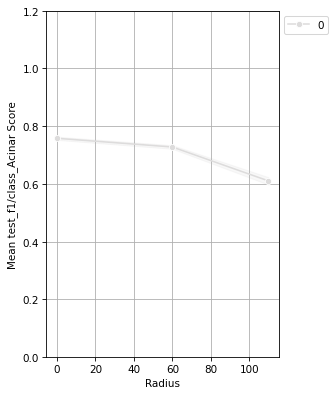

In [15]:
GNN_wandb.plot_robustness(metric="test_f1_class_Acinar", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

In [ ]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

In [ ]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{HPC}/InterScale_reproducibility/figures/melton25/graph_class")

  model        class      mean       std  n_seeds
0   GCN       Acinar  0.727444  0.006144        5
1   GCN        Alpha  0.613615  0.008895        5
2   GCN         Beta  0.501623  0.015985        5
3   GCN       Ductal  0.683614  0.006954        5
4   GCN    Endocrine  0.524932  0.009182        5
5   GCN  Endothelial  0.278813  0.030073        5
6   GCN       Immune  0.417904  0.006512        5
7   GCN         Mast  0.243032  0.004787        5


/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility/src/wandb.py:430: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


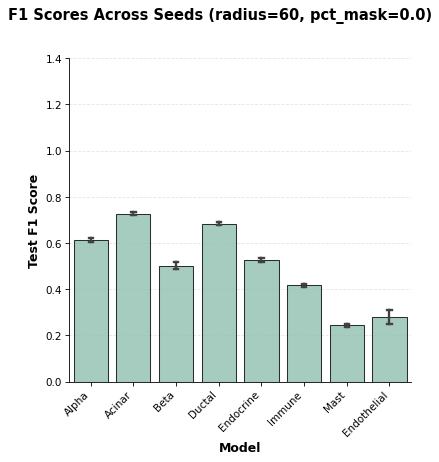

In [14]:
wandb_evals = [GNN_wandb]  # Your list of dataframes

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=60,
    pct_mask_nodes=0.0,
    config_path='config.yml',
    height=6,
    aspect=0.9
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

# Interpretation of CLS token

Given the sweep, we obtain the best model and check the CLS token.

In [ ]:
from InterScale.evaluation.graph_classification import scale_cls_by_sample#, plot_adata_grouped_heatmaps
import squidpy as sq

In [ ]:
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [ ]:
import InterScale as interscale

combined_model, model_config, adata = InterScale_wandb.load_model("test_f1/class_T1D")

In [ ]:
adata

In [ ]:
result_t1d = combined_model.get_model_output(adata[adata.obs['condition'] == 'T1D'], prefix = 'combined')
result_nd = combined_model.get_model_output(adata[adata.obs['condition'] == 'ND'], prefix = 'combined')

In [ ]:
scale_cls_by_sample(result_t1d, 'sliding_window_square')
scale_cls_by_sample(result_nd, "sliding_window_square")

In [ ]:
GROUP = 'cell_type_coarse'
fig = plot_adata_grouped_heatmaps(
        adata_dict={'ND': result_nd, 'T1D': result_t1d},
        group_by=GROUP,
        #value_cols=['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'],
    agg_func='mean',
        figsize=(10, 8),
        save_path=f"{HPC}/InterScale_reproducibility/figures/{DATA}/graph_class/cls_{GROUP}.png"
    )

In [ ]:
# assign cell type colors
color_list = [CELL_TYPE_COLORS[ct] for ct in adata.obs[GROUP].cat.categories]
result_t1d.uns[f'{GROUP}_colors'] = color_list
result_nd.uns[f'{GROUP}_colors'] = color_list

In [ ]:
image_nr_long = np.unique(result_t1d.obs['slide_fov'][result_t1d.obs['split'] == 'test'])
image_subset = list(np.random.choice(image_nr_long, 2))
sq.pl.spatial_scatter(result_t1d[result_t1d.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', GROUP],
                      library_key = 'slide_fov',
                      library_id = image_subset,
                    cmap = PALETTE,
                    shape= None,
                      ncols = 3,
                      size = 50,
                      save = f"{HPC}/InterScale_reproducibility/figures/{DATA}/graph_class/"
)